<a href="https://colab.research.google.com/github/visheshgupta19/Explainable-Deep-Learning/blob/main/Explainable_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 33.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=43301435ec004c6c6c11f4549280e3c3a4a85c82a11396d65df84612248c4970
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
from google.colab import drive
import requests
from io import BytesIO


from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

As mentioned in our instructions we need to use a pretrained computer vision model (e.g., ResNet-50, ViT) for your classification task. I decided to go ahead and use ResNet-50.

1. I  will load ResNet-50 with our it being pretrained. We will then set it to evaluation model which is important as it disables behaviors specific to training such as dropout and running batch normalization updates.
2. I need to define the preprocessing pipeline. This ensures that the input images are transformed into the format that ResNet expects.

  - Resize to 224×224 pixels
  - Turns images into PyTorch tensors and scales pixel values from [0, 255] into [0, 1]
  - Applies channel-wise normalization using the ImageNet dataset statistics (mean and std).

In [3]:
model = models.resnet50(pretrained=True)
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 83.9MB/s]


In [ ]:
'''
To select my variants I ran a ChatGpt prompt which was:
variants within pytorch_grad_cam library for grad cam

Response I got was:

The pytorch-grad-cam library (by Jacob Gildenblat) provides several Grad-CAM variants for visualizing class activation maps from CNNs and vision models.
Here are the main ones included in the library:
🔑 Grad-CAM Variants in pytorch-grad-cam
GradCAM
The classic Grad-CAM (Selvaraju et al., 2017).
Uses gradients of the target class flowing into the final convolutional layers to produce localization maps.
GradCAMPlusPlus
An improved version (Chattopadhyay et al., 2018).
Handles multiple occurrences of the same class in an image better by refining the gradient weighting scheme.
ScoreCAM
Gradient-free method (Wang et al., 2020).
Perturbs the input with feature maps, measures class score increase, and uses that as weights.
More stable but computationally heavier since it requires multiple forward passes.
AblationCAM
Gradient-free and more efficient alternative to ScoreCAM.
Measures drop in target score when ablating feature maps to assign importance.
XGradCAM
A variant that modifies the weight calculation to improve localization accuracy.
EigenCAM
Doesn’t use gradients at all.
Uses principal components of the activations to generate the heatmap.
Works even when gradients are not available (e.g., non-differentiable ops).
EigenGradCAM
Combines EigenCAM and Grad-CAM ideas.
Uses both gradients and PCA-based activation analysis.
'''

target_layer = model.layer4[-1]

cam_methods = {
    "GradCAM": GradCAM(model=model, target_layers=[target_layer]),
    "GradCAM++": GradCAMPlusPlus(model=model, target_layers=[target_layer]),
    "ScoreCAM": ScoreCAM(model=model, target_layers=[target_layer])
    }

In [6]:
'''
The prompt I gave ChatGpt was: How can I have contents of my drive available to anyone that runs my google colab notebook.
File name is dataset-resized. Pick the first image in each subfolder after you access it.
'''
# drive.mount('/content/drive')
# dataset_folder = '/content/drive/MyDrive/dataset-resized'
# print(os.listdir(dataset_folder))

# class_folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]

# # Pick one image per class
# sample_images = {}
# for cls in class_folders:
#     folder_path = os.path.join(dataset_folder, cls)
#     images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
#     if images:
#         sample_images[cls] = os.path.join(folder_path, images[0])  # pick first image

My initial approach was to mount Google Drive and automatically pick one image per class directly from the dataset folder as seen above however it turned our that since the dataset was large storing and repeatedly accessing it from Drive became inefficient.

*source: https://github.com/garythung/trashnet*

To combat this I directly linked the smaller set of images that I have uploaded on GitHub

In [ ]:
sample_images = {
    'trash':'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/trash9.jpg',
    'glass':'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/glass9.jpg',
    'metal':'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/metal7.jpg',
    'cardboard':'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/cardboard3.jpg',
    'plastic':'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/plastic4.jpg'
}

In [8]:
sample_images

{'trash': 'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/trash9.jpg',
 'glass': 'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/glass9.jpg',
 'metal': 'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/metal7.jpg',
 'cardboard': 'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/cardboard3.jpg',
 'plastic': 'https://raw.githubusercontent.com/visheshgupta19/Explainable-Deep-Learning/main/images/plastic4.jpg'}

To help with the build up and analysis I created two main helper functions:

1. load_image_local: To ensure we have a safe and consistent way to load images from the dataset we have I created a function that converts the image into an RGB format. This is done before preprocessing and passing them into the model.

2. cam_overlap: This functions helps me compare two heat maps and get their average overlap by taking the element-wise minimum and averaging. This function is helpful for us to understand and compare between the methods.



In [ ]:
def load_image_local(path):
    try:
        img = Image.open(path).convert("RGB")
        return img
    except:
        print(f"Error loading image: {path}")
        return None

def cam_overlap(cam1, cam2):
    cam1_norm = cam1 / cam1.max()
    cam2_norm = cam2 / cam2.max()
    return np.mean(np.minimum(cam1_norm, cam2_norm))

I then created a function that will allow me to visualize and interpret class activation maps with a number of different variants. This function also allows and makes it easy for us to see which parts of the image the model is looking at for its prediction. Once the image has been preprocessed by implementing preprocessing pipelines and adding batch dimensions the model will then make predictions, which will then produces class probabilities. From these, the function calculates the predicted class and probability. The function then plots a figure to display the original image and one heatmap of each CAM strategy. For each CAM strategy (GradCAM, GradCAM++, ScoreCAM), it computes a grayscale heatmap that identifies important regions for the prediction. The function then takes the grayscale heatmap to overlay onto the original image to create a colored visualization. For comparison purposes, within the function I calculate the salient fraction that is the proportion of the image that the CAM considers significant. Lastly, I calculate the overlap among our 3 heatmaps to check how much their highlighted regions are similar to each other.

In [11]:
def apply_cams(img_pil, label, true_class_index=None):
    input_tensor = preprocess(img_pil).unsqueeze(0)

    outputs = model(input_tensor)
    probs = F.softmax(outputs, dim=1)
    pred_class = outputs.argmax(dim=1).item()
    pred_prob = probs[0, pred_class].item()

    rgb_img = np.array(img_pil.resize((224,224))) / 255.0

    fig, axes = plt.subplots(1, len(cam_methods)+1, figsize=(18,5))
    axes[0].imshow(img_pil)
    axes[0].set_title(f"Original: {label}\nPredicted: {pred_class} ({pred_prob:.2f})")
    axes[0].axis("off")

    cam_results = {}
    for i, (name, cam) in enumerate(cam_methods.items(), 1):
        if true_class_index is not None:
            target = [ClassifierOutputTarget(true_class_index)]
        else:
            target = None

        grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0, :]
        cam_results[name] = grayscale_cam

        salient_area = (grayscale_cam > 0.5).sum() / grayscale_cam.size
        print(f"{name} salient fraction: {salient_area:.2f}")

        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        axes[i].imshow(cam_image)
        axes[i].set_title(name)
        axes[i].axis("off")

        # save_path = f"cam_results/{label}_{name}.png"
        # cv2.imwrite(save_path, cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR))

    plt.show()

    overlap_gc_gcpp = cam_overlap(cam_results["GradCAM"], cam_results["GradCAM++"])
    overlap_gc_sc = cam_overlap(cam_results["GradCAM"], cam_results["ScoreCAM"])
    overlap_sc_gcpp = cam_overlap(cam_results["ScoreCAM"], cam_results["GradCAM++"])
    print(f"GradCAM vs GradCAM++ overlap: {overlap_gc_gcpp:.2f}\n")
    print(f"GradCAM vs ScoreCAM overlap: {overlap_gc_sc:.2f}\n")
    print(f"ScoreCAM vs GradCAM++ overlap: {overlap_sc_gcpp:.2f}\n")

GradCAM salient fraction: 0.25
GradCAM++ salient fraction: 0.25


100%|██████████| 128/128 [06:36<00:00,  3.10s/it]


ScoreCAM salient fraction: 0.23


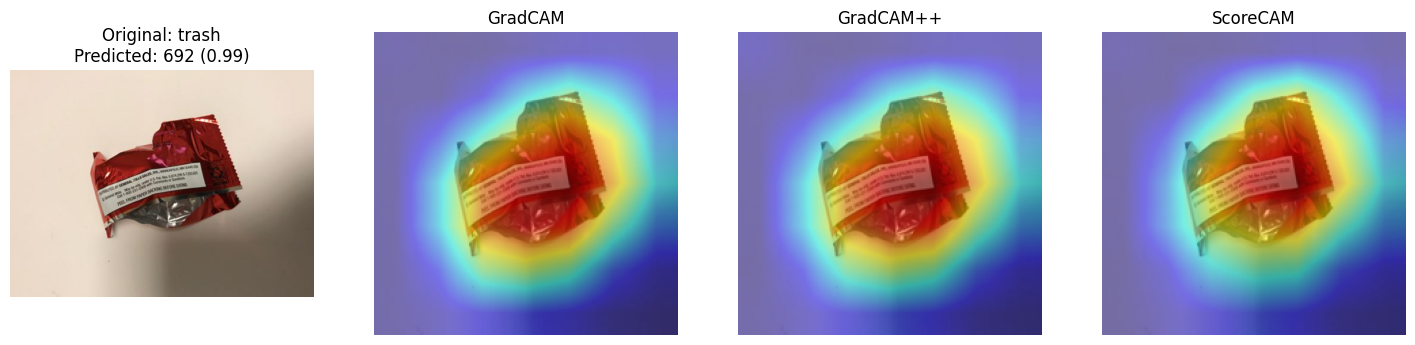

GradCAM vs GradCAM++ overlap: 0.30

GradCAM vs ScoreCAM overlap: 0.27

ScoreCAM vs GradCAM++ overlap: 0.28

GradCAM salient fraction: 0.22
GradCAM++ salient fraction: 0.25


100%|██████████| 128/128 [07:00<00:00,  3.28s/it]


ScoreCAM salient fraction: 0.31


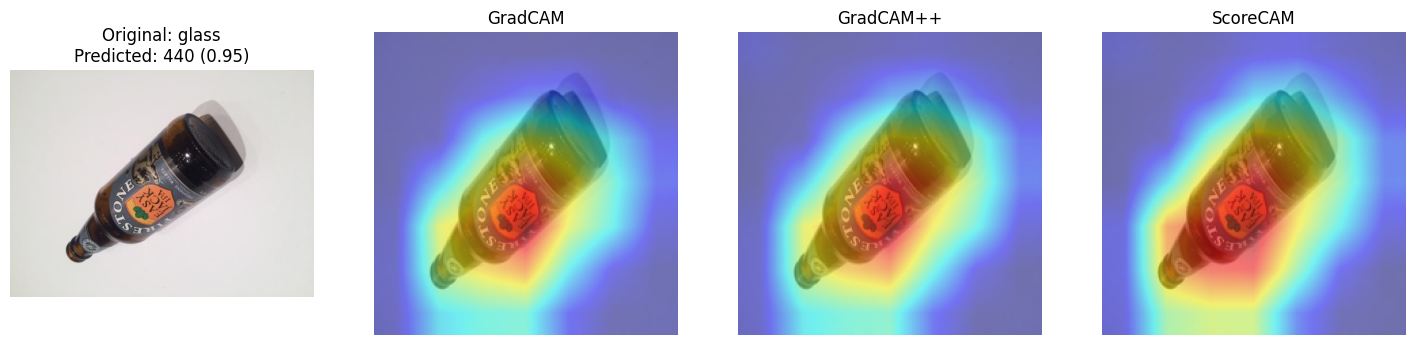

GradCAM vs GradCAM++ overlap: 0.26

GradCAM vs ScoreCAM overlap: 0.26

ScoreCAM vs GradCAM++ overlap: 0.29

GradCAM salient fraction: 0.21
GradCAM++ salient fraction: 0.23


100%|██████████| 128/128 [07:55<00:00,  3.71s/it]


ScoreCAM salient fraction: 0.20


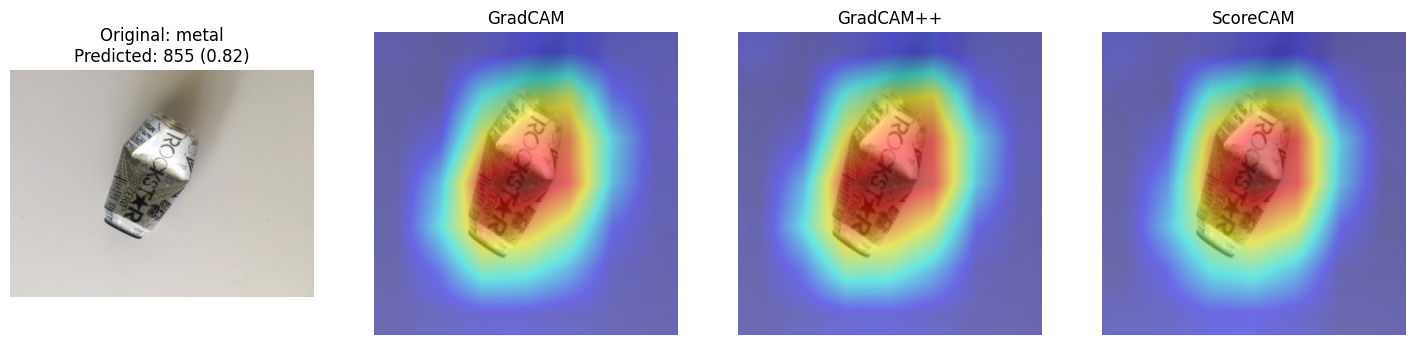

GradCAM vs GradCAM++ overlap: 0.26

GradCAM vs ScoreCAM overlap: 0.24

ScoreCAM vs GradCAM++ overlap: 0.25

GradCAM salient fraction: 0.23
GradCAM++ salient fraction: 0.26


100%|██████████| 128/128 [07:36<00:00,  3.57s/it]


ScoreCAM salient fraction: 0.43


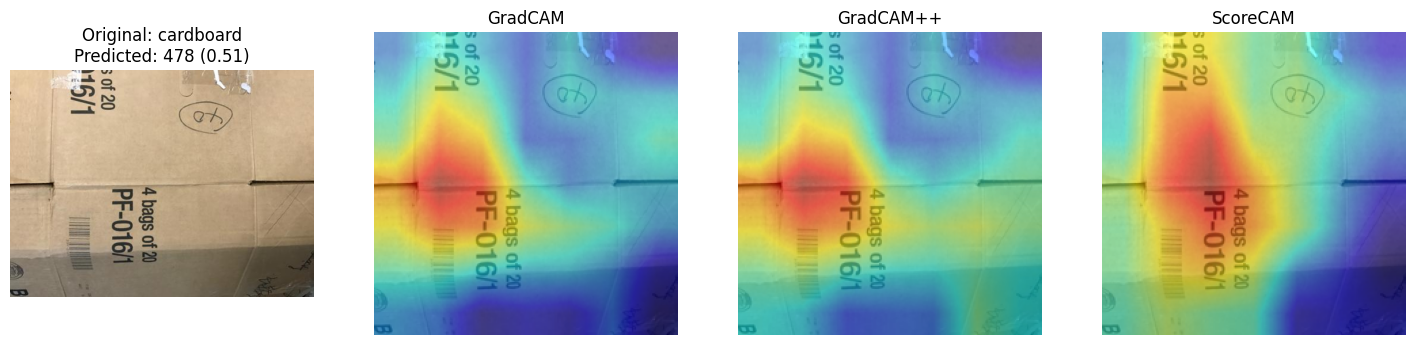

GradCAM vs GradCAM++ overlap: 0.36

GradCAM vs ScoreCAM overlap: 0.34

ScoreCAM vs GradCAM++ overlap: 0.35

GradCAM salient fraction: 0.23
GradCAM++ salient fraction: 0.24


100%|██████████| 128/128 [07:11<00:00,  3.37s/it]


ScoreCAM salient fraction: 0.29


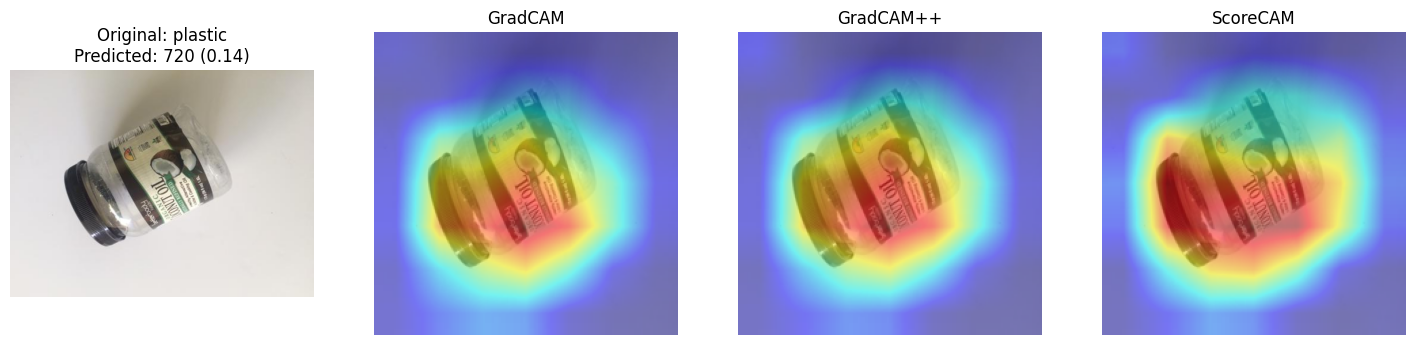

GradCAM vs GradCAM++ overlap: 0.27

GradCAM vs ScoreCAM overlap: 0.28

ScoreCAM vs GradCAM++ overlap: 0.28



In [12]:
for label, url in sample_images.items():
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    apply_cams(img, label)